Saved: /Users/nandan/Desktop/CTCs/IBM/em1_bar_comparison.png
Saved: /Users/nandan/Desktop/CTCs/IBM/em1_bar_comparison.pdf


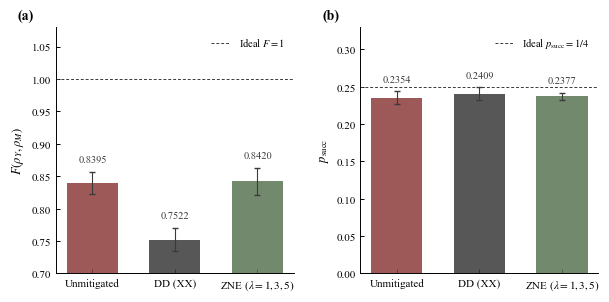

In [2]:
"""
Figure: Error-mitigation comparison on ibm_torino
Unmitigated vs Dynamical Decoupling (XX) vs ZNE (lambda = 1, 3, 5)

PRL-style: two-panel, Times serif, inward ticks, muted palette consistent with
the rest of the paper. No on-plot title; no in-bar value labels.
"""
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------- Data ----------------
with open("error_mitigation_results.json") as f:
    d = json.load(f)

r = d["results"]
methods = ["unmitigated", "dd", "zne"]
labels  = ["Unmitigated", "DD (XX)", r"ZNE ($\lambda=1,3,5$)"]

F      = np.array([r[m]["F"]    for m in methods])
F_lo   = np.array([r[m]["F_lo"] for m in methods])
F_hi   = np.array([r[m]["F_hi"] for m in methods])
p      = np.array([r[m]["p_succ"] for m in methods])

# ZNE p_succ CI: bootstrap over the per-lambda binomial estimates.
# Each lambda has n_total=10000 shots; ZNE p_succ is the mean over lambdas.
_rng = np.random.default_rng(0)
_p_lams = np.array(list(r["zne"]["p_at_lambda"].values()))
_n = d["metadata"]["shots"]
_boot = np.empty(5000)
for _i in range(5000):
    _samp = _rng.binomial(_n, _p_lams) / _n
    _boot[_i] = _samp.mean()
zne_p_lo, zne_p_hi = np.percentile(_boot, [2.5, 97.5])

p_lo   = np.array([r["unmitigated"]["p_lo"], r["dd"]["p_lo"], zne_p_lo])
p_hi   = np.array([r["unmitigated"]["p_hi"], r["dd"]["p_hi"], zne_p_hi])

F_err = np.vstack([F - F_lo, F_hi - F])
p_err = np.vstack([p - p_lo, p_hi - p])

shots = d["metadata"]["shots"]

# ---------------- PRL rcParams ----------------
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":    "stix",
    "font.size":           8,
    "axes.labelsize":      9,
    "axes.titlesize":      9,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "legend.fontsize":     7.5,
    "axes.linewidth":      0.7,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    "xtick.minor.width":   0.5,
    "ytick.minor.width":   0.5,
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "xtick.minor.size":    1.6,
    "ytick.minor.size":    1.6,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           False,
    "ytick.right":         False,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":        "tight",
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# Consistent paper palette
C_PS    = "#5b7553"   # sage  — favored / ideal-tier
C_DYN   = "#8c3b3b"   # brick — degraded / hardware baseline
C_THIRD = "#c08a3e"   # warm ochre — third category (ZNE)
C_GREY  = "#3a3a3a"



# Unmitigated -> brick (baseline), DD -> grey (passive mitigation), ZNE -> sage (best)
bar_colors = [C_DYN, C_GREY, C_PS]

# ---------------- Figure ----------------
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(7.0, 3.2), gridspec_kw={"wspace": 0.28}
)

x = np.arange(len(methods))
bar_w = 0.62

# ============ LEFT: fidelity ============
axL.bar(x, F, width=bar_w,
        color=bar_colors, edgecolor="none", alpha=0.85, zorder=2)
axL.errorbar(x, F, yerr=F_err, fmt="none",
             ecolor=C_GREY, elinewidth=0.8, capsize=2.5, zorder=3)

# Value labels above each error bar
for xi, Fi, Fhi in zip(x, F, F_hi):
    axL.text(xi, Fhi + 0.012, f"{Fi:.4f}",
             ha="center", va="bottom", fontsize=7.5, color=C_GREY)

# Ideal F=1 reference
axL.axhline(1.0, color=C_GREY, lw=0.7, linestyle=(0,(3,2)),
            label=r"Ideal $F = 1$")

axL.set_xticks(x)
axL.set_xticklabels(labels)
axL.set_ylabel(r"$F(\rho_Y,\rho_M)$")
axL.set_ylim(0.70, 1.08)
axL.legend(loc="upper right", frameon=False, handlelength=1.8)

axL.text(-0.16, 1.02, "(a)", transform=axL.transAxes,
         fontsize=10, fontweight="bold", va="bottom")

# ============ RIGHT: post-selection rate ============
axR.bar(x, p, width=bar_w,
        color=bar_colors, edgecolor="none", alpha=0.85, zorder=2)
# Error bars only where CI exists (drop NaN cleanly)
for i in range(len(methods)):
    if not np.isnan(p_err[0, i]):
        axR.errorbar(x[i], p[i],
                     yerr=[[p_err[0, i]], [p_err[1, i]]],
                     fmt="none", ecolor=C_GREY,
                     elinewidth=0.8, capsize=2.5, zorder=3)

# Value labels above each bar (above the upper CI)
for i in range(len(methods)):
    y_top = p_hi[i] if not np.isnan(p_hi[i]) else p[i]
    axR.text(x[i], y_top + 0.010, f"{p[i]:.4f}",
             ha="center", va="bottom", fontsize=7.5, color=C_GREY)

axR.axhline(0.25, color=C_GREY, lw=0.7, linestyle=(0,(3,2)),
            label=r"Ideal $p_{\mathrm{succ}} = 1/4$")

axR.set_xticks(x)
axR.set_xticklabels(labels)
axR.set_ylabel(r"$p_{\mathrm{succ}}$")
axR.set_ylim(0.0, 0.33)
axR.legend(loc="upper right", frameon=False, handlelength=1.8)

axR.text(-0.16, 1.02, "(b)", transform=axR.transAxes,
         fontsize=10, fontweight="bold", va="bottom")

# ---------------- Save ----------------
out_png = "/Users/nandan/Desktop/CTCs/IBM/em1_bar_comparison.png"
out_pdf = "/Users/nandan/Desktop/CTCs/IBM/em1_bar_comparison.pdf"
plt.savefig(out_png, dpi=600)
plt.savefig(out_pdf)
print("Saved:", out_png)
print("Saved:", out_pdf)

In [2]:
"""
Publication-style figure: Error-mitigation comparison on ibm_torino.

Design choice:
- Uses a dot-and-whisker / forest-plot style instead of bars.
- This emphasizes point estimates and 95% CIs without implying a meaningful
  zero baseline for fidelity or post-selection probability.
- No on-plot title and no numerical labels; put exact values in the caption/table.
"""

import argparse
import json
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# ---------------- Helpers ----------------
def bootstrap_zne_psucc_ci(p_lams, n_shots, n_boot=20000, seed=0):
    """
    Bootstrap the ZNE p_succ CI from per-lambda binomial estimates.
    Each lambda uses n_shots shots; ZNE p_succ is the mean over lambdas.
    """
    rng = np.random.default_rng(seed)
    p_lams = np.asarray(p_lams, dtype=float)

    # Vectorized bootstrap: shape = (n_boot, n_lambdas)
    samp = rng.binomial(n_shots, p_lams, size=(n_boot, p_lams.size)) / n_shots
    boot = samp.mean(axis=1)
    return np.percentile(boot, [2.5, 97.5])


def load_data(json_path):
    with open(json_path, "r") as f:
        d = json.load(f)

    r = d["results"]
    methods = ["unmitigated", "dd", "zne"]
    labels = ["Unmitigated", "DD (XX)", r"ZNE ($\lambda=1,3,5$)"]

    F = np.array([r[m]["F"] for m in methods], dtype=float)
    F_lo = np.array([r[m]["F_lo"] for m in methods], dtype=float)
    F_hi = np.array([r[m]["F_hi"] for m in methods], dtype=float)

    p = np.array([r[m]["p_succ"] for m in methods], dtype=float)

    # ZNE p_succ CI is not stored directly in your JSON, so compute it.
    shots = int(d["metadata"]["shots"])
    p_lams = np.array(list(r["zne"]["p_at_lambda"].values()), dtype=float)
    zne_p_lo, zne_p_hi = bootstrap_zne_psucc_ci(p_lams, shots)

    p_lo = np.array([r["unmitigated"]["p_lo"], r["dd"]["p_lo"], zne_p_lo], dtype=float)
    p_hi = np.array([r["unmitigated"]["p_hi"], r["dd"]["p_hi"], zne_p_hi], dtype=float)

    F_err = np.vstack([F - F_lo, F_hi - F])
    p_err = np.vstack([p - p_lo, p_hi - p])

    return d, methods, labels, F, F_lo, F_hi, F_err, p, p_lo, p_hi, p_err


# ---------------- Style ----------------
def set_paper_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",

        "font.size": 8,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,

        "axes.linewidth": 0.7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "xtick.minor.width": 0.5,
        "ytick.minor.width": 0.5,

        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 1.6,
        "ytick.minor.size": 1.6,

        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": False,
        "ytick.right": False,
        "axes.spines.top": False,
        "axes.spines.right": False,

        "legend.frameon": False,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


# Muted, print-safe palette.
COLORS = {
    "unmitigated": "#8A4B3F",  # muted brick
    "dd":          "#666A6D",  # slate gray
    "zne":         "#4F7C5C",  # muted sage
}
MARKERS = {
    "unmitigated": "o",
    "dd":          "s",
    "zne":         "D",
}

C_REF = "#2F2F2F"
C_GUIDE = "#E7E7E7"


# ---------------- Figure ----------------
def make_figure(json_path, out_prefix, width="double"):
    set_paper_style()

    d, methods, labels, F, F_lo, F_hi, F_err, p, p_lo, p_hi, p_err = load_data(json_path)

    # Double-column is a good default for a two-panel figure.
    # Single-column works too, but the long ZNE label becomes tight.
    figsize = (6.8, 2.25) if width == "double" else (3.45, 3.35)

    fig, (axL, axR) = plt.subplots(
        1, 2,
        figsize=figsize,
        sharey=True,
        constrained_layout=True,
        gridspec_kw={"wspace": 0.08},
    )

    # Put first method at the top.
    y = np.arange(len(methods))[::-1]

    for yi, method, label, Fi, Ferr_lo, Ferr_hi, pi, perr_lo, perr_hi in zip(
        y, methods, labels, F, F_err[0], F_err[1], p, p_err[0], p_err[1]
    ):
        color = COLORS[method]
        marker = MARKERS[method]

        axL.errorbar(
            Fi, yi,
            xerr=[[Ferr_lo], [Ferr_hi]],
            fmt=marker,
            ms=5.2,
            mfc=color,
            mec=C_REF,
            mew=0.45,
            ecolor=color,
            elinewidth=1.0,
            capsize=2.5,
            capthick=0.8,
            zorder=3,
        )

        axR.errorbar(
            pi, yi,
            xerr=[[perr_lo], [perr_hi]],
            fmt=marker,
            ms=5.2,
            mfc=color,
            mec=C_REF,
            mew=0.45,
            ecolor=color,
            elinewidth=1.0,
            capsize=2.5,
            capthick=0.8,
            zorder=3,
        )

    # Light row guides help the reader align methods across panels.
    for ax in (axL, axR):
        for yi in y:
            ax.axhline(yi, color=C_GUIDE, lw=0.55, zorder=0)
        ax.set_yticks(y)
        ax.set_ylim(-0.6, len(methods) - 0.4)

    axL.set_yticklabels(labels)
    axR.tick_params(axis="y", labelleft=False, length=0)

    # Ideal reference lines.
    axL.axvline(1.0, color=C_REF, lw=0.75, linestyle=(0, (3, 2)), zorder=1)
    axR.axvline(0.25, color=C_REF, lw=0.75, linestyle=(0, (3, 2)), zorder=1)

    axL.text(
        0.985, 1.025, r"Ideal $F=1$",
        transform=axL.get_xaxis_transform(),
        ha="right", va="bottom", fontsize=7.5, color=C_REF,
    )
    axR.text(
        0.2497, 1.025, r"Ideal $p_{\rm succ}=1/4$",
        transform=axR.get_xaxis_transform(),
        ha="right", va="bottom", fontsize=7.5, color=C_REF,
    )

    axL.set_xlabel(r"$F(\rho_Y,\rho_M)$")
    axR.set_xlabel(r"$p_{\mathrm{succ}}$")

    # Axis ranges chosen to show uncertainty clearly while keeping ideal references visible.
    axL.set_xlim(0.70, 1.015)
    axR.set_xlim(0.220, 0.255)

    axL.xaxis.set_major_locator(MultipleLocator(0.10))
    axL.xaxis.set_minor_locator(MultipleLocator(0.05))
    axR.xaxis.set_major_locator(MultipleLocator(0.01))
    axR.xaxis.set_minor_locator(MultipleLocator(0.005))

    # Panel labels.
    axL.text(-0.17, 1.06, "(a)", transform=axL.transAxes,
             fontsize=10, fontweight="bold", va="bottom")
    axR.text(-0.10, 1.06, "(b)", transform=axR.transAxes,
             fontsize=10, fontweight="bold", va="bottom")

    out_prefix = Path(out_prefix)
    out_prefix.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(out_prefix.with_suffix(".png"), dpi=600)
    fig.savefig(out_prefix.with_suffix(".pdf"))
    fig.savefig(out_prefix.with_suffix(".svg"))
    plt.close(fig)

    # Also print exact values for captions/tables.
    print("Exact values:")
    for label, Fi, Flo, Fhi, pi, plo, phi in zip(labels, F, F_lo, F_hi, p, p_lo, p_hi):
        print(f"{label}: F={Fi:.4f} [{Flo:.4f}, {Fhi:.4f}], "
              f"p_succ={pi:.4f} [{plo:.4f}, {phi:.4f}]")


# def main():
#     parser = argparse.ArgumentParser()
#     parser.add_argument(
#         "--json",
#         default="error_mitigation_results.json",
#         help="Path to error_mitigation_results.json",
#     )
#     parser.add_argument(
#         "--out",
#         default="em1_journal_comparison",
#         help="Output prefix without extension",
#     )
#     parser.add_argument(
#         "--width",
#         choices=["double", "single"],
#         default="double",
#         help="Figure sizing preset",
#     )
#     args = parser.parse_args()
#     make_figure(args.json, args.out, args.width)


# if __name__ == "__main__":
#     main()


usage: ipykernel_launcher.py [-h] [--json JSON] [--out OUT]
                             [--width {double,single}]
ipykernel_launcher.py: error: unrecognized arguments: --f=/Users/nandan/Library/Jupyter/runtime/kernel-v3b0487d9cfdf40546d8495c81fa205039e39ee67d.json


SystemExit: 2

In [7]:
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--json", default="error_mitigation_results.json")
    parser.add_argument("--out", default="em1_journal_comparison")
    parser.add_argument("--width", choices=["double", "single"], default="double")

    # Use parse_known_args so Jupyter/IPython kernel arguments are ignored.
    args, _unknown = parser.parse_known_args()

    make_figure(
        json_path=args.json,
        out_prefix=args.out,
        width=args.width,
    )


if __name__ == "__main__":
    main()

Exact values:
Unmitigated: F=0.8395 [0.8223, 0.8568], p_succ=0.2354 [0.2271, 0.2438]
DD (XX): F=0.7522 [0.7346, 0.7703], p_succ=0.2409 [0.2325, 0.2494]
ZNE ($\lambda=1,3,5$): F=0.8420 [0.8217, 0.8629], p_succ=0.2377 [0.2321, 0.2417]
